# S3-1 デュレーションとコンベクシティ

## 学習目標

- マコーレー・修正・実効デュレーションの定義の違いを、それぞれが何を測る量か
  まで含めて説明できる
- コンベクシティを定義し、テイラー展開から価格変化の2次近似を導出できる
- 2次近似が壊れる条件（大きな金利変化・キャッシュフローが金利に依存する商品）を
  数式と数値で示せる
- 負のコンベクシティが生じる仕組みを理解し、コーラブル債・MBS への伏線をつかむ
- デュレーション・コンベクシティを解析式とバンプ法（数値微分）の両方で実装し、
  `bondlab.analytics` と QuantLib に機械精度で一致させられる

## 実務での位置づけ（ファンドはどう稼ぐか）

デュレーションとコンベクシティは、債券ポジションが金利変化でいくら動くかを一つの数字に落とす、最も基礎的なリスク指標です。使い手はまずリスク管理クオンツで、トレーダーが抱える国債・スワップの在庫を毎日デュレーションで束ねて「この本の金利1%上昇でいくら損するか」を経営に報告します。次に運用会社・保険・年金のALM担当で、負債側のデュレーションに資産側を合わせて金利変動の影響を相殺する免疫化（イミュナイゼーション）を組みます。マクロやレラティブバリューのファンドでも、方向観に賭ける前に「意図した金利感応度だけを残し、それ以外は消す」ための単位としてデュレーションを使います。

収益とリスク管理への繋がりは二段構えです。第一に、デュレーションは損失を測る物差しであり、ポジション上限（DV01リミット・VaRリミット）の土台になります。第二に、コンベクシティそのものが収益源になります。価格・利回り関係が下に凸であるため、金利が大きく動くとロング側は近似より得をし、ショート側は損をします。この非対称性を買う／売るのがコンベクシティ取引で、オプション性の対価（キャリー）と釣り合う水準かどうかを見極めます。修正デュレーションで組んだヘッジは1次近似にすぎず、金利が大きく振れた日には $\tfrac{1}{2}\,C\,(\Delta y)^2$ の残差が必ず残ります。この残差を無視すると、ヘッジ済みのつもりのポジションが決算日に想定外のPnLを生みます。

具体的な場面として、コーラブル債やMBSは金利低下時に期限前償還が進んでデュレーションが縮み、負のコンベクシティを持ちます。これを保有するファンドは、金利が動くほど不利になる方向にさらされているため、コンベクシティを別途ヘッジしなければリスクを取り過ぎます。デュレーション・コンベクシティを解析式とバンプ法の両方で正しく計算できないと、そもそもポジションの金利リスクを数値化できず、リミット管理もヘッジ設計もキャリーの妥当性判断も成り立ちません。


## 理論

### 記号と価格式

額面 100、年 $f$ 回利払いの固定利付債を考える。決済日から測った各キャッシュ
フローの割引指数を $n_j$（street convention では $n_j = w + j$、$w$ は次
クーポンまでの残り期間割合、$j=0,1,\dots$）、年数を $t_j = n_j/f$ とする。
半年複利利回りに揃えた最終利回り $y$ で割り引くと、ダーティ価格は

$$ P(y) \;=\; \sum_j c_j \left(1 + \frac{y}{f}\right)^{-n_j}. $$

以降の微分はすべてこの $P(y)$ を $y$ について解析的に取る。デュレーション系の
指標は「$P(y)$ の $y$ に対する感応度」を別々の基準で正規化したものにすぎない。

### マコーレーデュレーション（Macaulay duration）

キャッシュフローの現在価値を重みとした、回収までの加重平均年数として定義する。

$$ D_{\mathrm{mac}} \;=\; \frac{1}{P}\sum_j t_j\, c_j \left(1+\frac{y}{f}\right)^{-n_j}. $$

単位は年で、「投資の平均回収期間」という時間的な意味を持つ。ゼロクーポン債では
全キャッシュフローが満期に集中するため $D_{\mathrm{mac}}$ は残存年数に一致する。

### 修正デュレーション（modified duration）

価格の利回り弾力性を測る。$P(y)$ を微分すると、指数 $-n_j$ から

$$ \frac{dP}{dy} \;=\; \sum_j c_j \cdot (-n_j)\left(1+\frac{y}{f}\right)^{-n_j-1}\cdot\frac{1}{f}
   \;=\; -\frac{1}{1+y/f}\sum_j \frac{n_j}{f}\, c_j\left(1+\frac{y}{f}\right)^{-n_j}. $$

右辺の和は $P \cdot D_{\mathrm{mac}}$ に等しい（$n_j/f = t_j$）。したがって

$$ \frac{dP}{dy} \;=\; -\frac{D_{\mathrm{mac}}}{1+y/f}\,P \;\equiv\; -D_{\mathrm{mod}}\,P,
   \qquad D_{\mathrm{mod}} \;=\; \frac{D_{\mathrm{mac}}}{1+y/f}. $$

$D_{\mathrm{mod}}$ は「利回りが1（=100%）動いたときの価格の相対変化率」で、

$$ \frac{1}{P}\frac{dP}{dy} = -D_{\mathrm{mod}} $$

という関係を持つ。マコーレーとの違いは複利補正 $1/(1+y/f)$ の一項だけで、
マコーレーが「時間」を、修正が「価格感応度」を測る点に本質がある。

### DV01

利回りが $1\,\mathrm{bp}=10^{-4}$ 動いたときの価格の絶対変化額を

$$ \mathrm{DV01} \;=\; -\frac{dP}{dy}\times 10^{-4} \;=\; D_{\mathrm{mod}}\,P\times 10^{-4} $$

と定義する。ヘッジ数量の計算に直接使う実務量で、S3-2 で深掘りする。

### コンベクシティ（convexity）

価格の利回りに対する2階微分を価格で正規化した量として定義する。

$$ C \;=\; \frac{1}{P}\frac{d^2P}{dy^2}. $$

$P(y)$ の各項を2回微分すると

$$ \frac{d^2P}{dy^2} \;=\; \sum_j c_j\, n_j(n_j+1)\left(1+\frac{y}{f}\right)^{-n_j-2}\cdot\frac{1}{f^2}, $$

よって

$$ C \;=\; \frac{1}{P}\sum_j \frac{n_j(n_j+1)}{f^2}\, c_j\left(1+\frac{y}{f}\right)^{-n_j-2}. $$

$C$ は価格-利回り曲線の「曲がり具合」で、通常の債券では常に正になる。将来
キャッシュフローが正である限り2階微分の各項が正だからである。

### テイラー展開による価格変化の2次近似

利回りが $y_0$ から $\Delta y$ 動いたときの価格変化を $y_0$ まわりでテイラー展開する。

$$ P(y_0+\Delta y) \;=\; P(y_0) + \frac{dP}{dy}\Delta y + \frac12\frac{d^2P}{dy^2}\Delta y^2 + O(\Delta y^3). $$

両辺を $P(y_0)$ で割り、上で導いた関係を代入すると、価格変化率の近似式

$$ \frac{\Delta P}{P} \;\approx\; \underbrace{-\,D_{\mathrm{mod}}\,\Delta y}_{\text{1次（デュレーション項）}}
   \;+\; \underbrace{\tfrac12\, C\,\Delta y^2}_{\text{2次（コンベクシティ項）}} $$

を得る。1次項は $\Delta y$ に線形で符号を持つ（利回り上昇で価格下落）。2次項は
$\Delta y^2$ に比例し $C>0$ なら常に正、すなわち利回りがどちらへ動いても価格を
押し上げる方向に働く。これがコンベクシティの「保険」的な価値である。

### 実効デュレーション（effective duration）

解析式は「キャッシュフローが利回りに依存しない」ことを前提にしている。
コーラブル債・MBS のようにキャッシュフロー自体が金利で変わる商品では、上の
微分は正しくない。そこで価格関数 $P(\cdot)$ を有限差分でバンプして数値微分する。

$$ D_{\mathrm{eff}} \;=\; -\frac{P(y_0+\Delta y) - P(y_0-\Delta y)}{2\,\Delta y\, P(y_0)},
   \qquad
   C_{\mathrm{eff}} \;=\; \frac{P(y_0+\Delta y) - 2P(y_0) + P(y_0-\Delta y)}{\Delta y^2\, P(y_0)}. $$

中心差分は片側差分より打ち切り誤差が小さい（$O(\Delta y^2)$）。キャッシュフローが
固定の債券では $D_{\mathrm{eff}}=D_{\mathrm{mod}}$、$C_{\mathrm{eff}}=C$ に一致する。
一致することを本編で数値確認し、一致しなくなる商品を S6-4（コーラブル）と S8（MBS）で扱う。

### 2次近似が壊れる条件

2次近似の誤差は打ち切った3次以降の項、主に

$$ \frac{1}{6P}\frac{d^3P}{dy^3}\,\Delta y^3 $$

に支配される。ここから壊れる条件が読める。

- **$\Delta y$ が大きい**：誤差は $\Delta y^3$ で増える。数 bp なら1次でも十分だが、
  $\pm 200\,\mathrm{bp}$ 級のシフトでは2次項が効き、なお3次の残差が見え始める。
- **キャッシュフローが金利依存**：コーラブル債は利回り低下で発行体が期限前償還
  するため価格が頭打ちになり、価格-利回り曲線が上に凸から下に凸へ折れる。この
  領域では2階微分が負、すなわち**負のコンベクシティ**になり、正のコンベクシティを
  前提にした2次近似は価格を過大評価する。MBS も期限前償還で同じ挙動を示す。

負のコンベクシティの実例は S6-4（コーラブル債）で価格関数を実装して可視化する。
本編ではまず「固定キャッシュフローでは $C>0$」を確認し、その伏線として実効指標を
バンプ法で計算する枠組みを用意しておく。

**数値例**：$D_{\mathrm{mod}}=7.0303$、$C=56.50$ の債券に $\Delta y=+100\,\mathrm{bp}=0.01$ を入れると、$\frac{\Delta P}{P}\approx -7.0303\times0.01+\tfrac12\times56.50\times0.01^2=-7.030\%+0.283\%=-6.748\%$ です。完全再評価は $-6.756\%$ で、コンベクシティ項 $+0.283\%$ が1次近似の下振れをほぼ埋めます。


**数値例**：同じ債券（$D_{\mathrm{mod}}=7.0303$、ダーティ価格 $P=96.5374$）では $\mathrm{DV01}=7.0303\times 96.5374\times 10^{-4}=0.0679$ です。額面100あたり、利回りが $1\,\mathrm{bp}$ 上がると価格が約 $0.068$ 下がります。


**数値例**：本編の 10年・クーポン3%・最終利回り $y=3.5\%$（半年複利 $f=2$）の債券では $D_{\mathrm{mac}}=7.1533$ 年なので、修正デュレーションは $D_{\mathrm{mod}}=\dfrac{7.1533}{1+0.035/2}=7.0303$ 年です。複利補正 $1/(1+y/f)$ の一項だけ短くなります。


## スクラッチ実装

デュレーション・コンベクシティを (1) 解析式、(2) バンプ法（数値微分）の2通りで
自作し、両者と `bondlab.analytics` の一致を確認する。実装する自作関数は次の3つ。

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `analytic_risk(bond, ytm, settle)` | 債券, 利回り, 決済日 | `dict(macaulay, modified, convexity, dv01, dirty_price)` | 解析式でデュレーション系指標を計算 |
| `bump_risk(price_fn, y0, bump)` | 価格関数, 基準利回り, バンプ幅 | `dict(modified, convexity)` | 中心差分でデュレーション・コンベクシティを数値微分 |
| `taylor_approx(risk, price0, dy)` | 指標dict, 基準価格, 利回り変化 | `dict(linear, quadratic)` | 1次・2次のテイラー近似価格を返す |

In [1]:
import datetime as dt

import numpy as np

import bondlab
from bondlab.bond import FixedRateBond
from bondlab.analytics import duration_convexity, effective_duration

np.random.seed(0)
print("bondlab version:", bondlab.__version__)


def analytic_risk(bond, ytm, settle):
    """解析式で macaulay/modified/convexity/dv01/dirty_price を計算する。

    period_cashflows が返す割引指数 n=w+j と年数 t=n/f を使い、理論節で導いた
    3つの和（価格・加重平均・2階微分）をそのまま評価する。
    """
    f = bond.frequency
    n, cf = bond.period_cashflows(settle)
    disc = (1.0 + ytm / f) ** (-n)
    pv = cf * disc
    price = pv.sum()
    t = n / f
    macaulay = (t * pv).sum() / price
    modified = macaulay / (1.0 + ytm / f)
    convexity = (cf * n * (n + 1.0) * (1.0 + ytm / f) ** (-n - 2.0)).sum() / (f ** 2) / price
    dv01 = modified * price * 1e-4
    return dict(
        macaulay=float(macaulay),
        modified=float(modified),
        convexity=float(convexity),
        dv01=float(dv01),
        dirty_price=float(price),
    )


def bump_risk(price_fn, y0, bump=1e-4):
    """価格関数を中心差分でバンプし、修正デュレーションとコンベクシティを数値微分する。

    1階は (P(+h)-P(-h))/(2h)、2階は (P(+h)-2P(0)+P(-h))/h^2 を価格で正規化する。
    キャッシュフローが利回りに依存する商品にもそのまま使える実効指標の定義。
    """
    p_up = price_fn(y0 + bump)
    p_dn = price_fn(y0 - bump)
    p0 = price_fn(y0)
    modified = -(p_up - p_dn) / (2.0 * bump * p0)
    convexity = (p_up - 2.0 * p0 + p_dn) / (bump ** 2 * p0)
    return dict(modified=float(modified), convexity=float(convexity))


def taylor_approx(risk, price0, dy):
    """テイラー展開の1次・2次近似価格を返す。

    linear    = P0 (1 - Dmod dy)
    quadratic = P0 (1 - Dmod dy + 1/2 C dy^2)
    """
    lin = price0 * (1.0 - risk["modified"] * dy)
    quad = price0 * (1.0 - risk["modified"] * dy + 0.5 * risk["convexity"] * dy ** 2)
    return dict(linear=float(lin), quadratic=float(quad))

bondlab version: 0.0.1


### 3通りの一致確認

10年・半年利付・クーポン3%の債券を、決済日をクーポン日に置いて評価する。解析式
（自作）・バンプ法（自作）・`bondlab.analytics.duration_convexity` の3者を突合する。

In [2]:
issue = dt.date(2024, 6, 15)
maturity = dt.date(2034, 6, 15)
settle = dt.date(2026, 6, 15)
ytm = 0.035

bond = FixedRateBond(issue, maturity, coupon=0.03, frequency=2, convention="ACT/ACT", face=100.0)

ana = analytic_risk(bond, ytm, settle)
num = bump_risk(lambda y: bond.dirty_price(y, settle), ytm, bump=1e-5)
lib = duration_convexity(bond, ytm, settle)

print(f"{'指標':16s}{'解析式(自作)':>16s}{'バンプ法(自作)':>16s}{'bondlab':>16s}")
print(f"{'修正Dur':16s}{ana['modified']:>16.10f}{num['modified']:>16.10f}{lib['modified']:>16.10f}")
print(f"{'コンベクシティ':16s}{ana['convexity']:>16.8f}{num['convexity']:>16.8f}{lib['convexity']:>16.8f}")
print(f"{'マコーレーDur':16s}{ana['macaulay']:>16.10f}{'-':>16s}{lib['macaulay']:>16.10f}")
print(f"{'DV01':16s}{ana['dv01']:>16.10f}{'-':>16s}{lib['dv01']:>16.10f}")

# 解析式（自作）と bondlab は同一ロジックなので機械精度で一致する。
assert abs(ana["modified"] - lib["modified"]) < 1e-12
assert abs(ana["convexity"] - lib["convexity"]) < 1e-10
# バンプ法は打ち切り誤差が O(h^2) 残るので緩めの許容で一致を見る。
assert abs(num["modified"] - lib["modified"]) < 1e-5
assert abs(num["convexity"] - lib["convexity"]) < 1e-3
print("解析式・バンプ法・bondlab が一致しました")

指標                       解析式(自作)        バンプ法(自作)         bondlab
修正Dur               7.0303160984    7.0303161066    7.0303160984
コンベクシティ              56.50494536     56.50494678     56.50494536
マコーレーDur            7.1533466302               -    7.1533466302
DV01                0.0678688267               -    0.0678688267
解析式・バンプ法・bondlab が一致しました


### 実効デュレーションとの整合

`bondlab.analytics.effective_duration`（中心差分の汎用版）は、キャッシュフローが
固定の債券では修正デュレーションに一致する。バンプ幅を細かくすると打ち切り誤差が
縮む様子も確認する。

In [3]:
price_fn = lambda y: bond.dirty_price(y, settle)
for h in (1e-3, 1e-4, 1e-5):
    eff = effective_duration(price_fn, ytm, bump=h)
    print(f"bump={h:.0e}  effective_duration={eff:.10f}  誤差={abs(eff - lib['modified']):.2e}")
assert abs(effective_duration(price_fn, ytm, bump=1e-5) - lib["modified"]) < 1e-5
print("実効デュレーションは修正デュレーションに一致します（固定CF債）")

bump=1e-03  effective_duration=7.0303977983  誤差=8.17e-05
bump=1e-04  effective_duration=7.0303169154  誤差=8.17e-07
bump=1e-05  effective_duration=7.0303161066  誤差=8.21e-09
実効デュレーションは修正デュレーションに一致します（固定CF債）


## QuantLib検証

QuantLib の `BondFunctions.duration`（Modified / Macaulay）と `convexity` に突合
する。ACT/ACT は債券標準の `ActualActual.Bond`（ISMA 変種）を使い、スケジュールを
渡すことで自作実装と同じ日数基準に揃える。決済日をクーポン日に置けば端数調整が
消え、機械精度で一致する。

In [4]:
import QuantLib as ql

sched = ql.Schedule(
    ql.Date(15, 6, 2024),
    ql.Date(15, 6, 2034),
    ql.Period(ql.Semiannual),
    ql.NullCalendar(),
    ql.Unadjusted,
    ql.Unadjusted,
    ql.DateGeneration.Backward,
    False,
)
aa = ql.ActualActual(ql.ActualActual.Bond, sched)
qlb = ql.FixedRateBond(0, 100.0, sched, [0.03], aa)

d = ql.Date(15, 6, 2026)
ql.Settings.instance().evaluationDate = d
ir = ql.InterestRate(0.035, aa, ql.Compounded, ql.Semiannual)

ql_mod = ql.BondFunctions.duration(qlb, ir, ql.Duration.Modified, d)
ql_mac = ql.BondFunctions.duration(qlb, ir, ql.Duration.Macaulay, d)
ql_cvx = ql.BondFunctions.convexity(qlb, ir, d)

print(f"{'指標':16s}{'bondlab':>18s}{'QuantLib':>18s}{'差':>12s}")
print(f"{'修正Dur':16s}{lib['modified']:>18.12f}{ql_mod:>18.12f}{abs(lib['modified']-ql_mod):>12.1e}")
print(f"{'マコーレーDur':16s}{lib['macaulay']:>18.12f}{ql_mac:>18.12f}{abs(lib['macaulay']-ql_mac):>12.1e}")
print(f"{'コンベクシティ':16s}{lib['convexity']:>18.10f}{ql_cvx:>18.10f}{abs(lib['convexity']-ql_cvx):>12.1e}")

assert abs(lib["modified"] - ql_mod) < 1e-10
assert abs(lib["macaulay"] - ql_mac) < 1e-10
assert abs(lib["convexity"] - ql_cvx) < 1e-8
print("QuantLib と機械精度で一致しました")

指標                         bondlab          QuantLib           差
修正Dur               7.030316098442    7.030316098442     3.6e-15
マコーレーDur            7.153346630165    7.153346630165     4.4e-15
コンベクシティ              56.5049453574     56.5049453574     5.0e-14
QuantLib と機械精度で一致しました


## 実データ適用

合成の実在風銘柄で、$\pm 200\,\mathrm{bp}$ の大幅シフトに対する 1次近似・2次近似・
完全再評価の誤差を比較する。ネットワークは使わず、銘柄条件は notebook 内で定義する。
2本用意する。

- **10年 JGB 相当**：クーポン 0.8%、利回り 0.9% 近辺。低クーポンで長め。
- **10年 UST 相当**：クーポン 4.25%、利回り 4.3% 近辺。

完全再評価 $P(y_0+\Delta y)$ を真値とし、1次・2次近似との差を bp（価格比）で測る。

In [5]:
import pandas as pd

instruments = {
    "10年JGB相当 (0.8%)": dict(
        issue=dt.date(2024, 6, 20), maturity=dt.date(2034, 6, 20), coupon=0.008, ytm=0.009
    ),
    "10年UST相当 (4.25%)": dict(
        issue=dt.date(2024, 6, 15), maturity=dt.date(2034, 6, 15), coupon=0.0425, ytm=0.043
    ),
}
settle_real = dt.date(2026, 6, 15)
shifts_bp = np.array([-200, -100, -50, -25, 25, 50, 100, 200], dtype=float)

rows = []
for name, spec in instruments.items():
    b = FixedRateBond(spec["issue"], spec["maturity"], spec["coupon"], 2, "ACT/ACT", 100.0)
    y0 = spec["ytm"]
    risk = analytic_risk(b, y0, settle_real)
    p0 = risk["dirty_price"]
    for s in shifts_bp:
        dy = s / 1e4
        p_true = b.dirty_price(y0 + dy, settle_real)
        approx = taylor_approx(risk, p0, dy)
        err_lin = (approx["linear"] - p_true) / p0 * 1e4     # bp of price
        err_quad = (approx["quadratic"] - p_true) / p0 * 1e4  # bp of price
        rows.append(dict(
            銘柄=name, シフトbp=int(s), 真値=p_true,
            _1次誤差bp=err_lin, _2次誤差bp=err_quad,
        ))

df = pd.DataFrame(rows)
df_show = df.rename(columns={"_1次誤差bp": "1次近似誤差(bp)", "_2次誤差bp": "2次近似誤差(bp)"})
df_show["真値"] = df_show["真値"].round(4)
df_show["1次近似誤差(bp)"] = df_show["1次近似誤差(bp)"].round(2)
df_show["2次近似誤差(bp)"] = df_show["2次近似誤差(bp)"].round(3)
display(df_show)

,銘柄,シフトbp,真値,1次近似誤差(bp),2次近似誤差(bp)
0,10年JGB相当 (0.8%),-200,116.3523,-137.50,-8.082
1,10年JGB相当 (0.8%),-100,107.6322,-33.34,-0.986
2,10年JGB相当 (0.8%),-50,103.5406,-8.21,-0.122
3,10年JGB相当 (0.8%),-25,101.5584,-2.04,-0.015
4,10年JGB相当 (0.8%),25,97.7169,-2.01,0.015
5,10年JGB相当 (0.8%),50,95.8556,-7.97,0.119
6,10年JGB相当 (0.8%),100,92.2479,-31.41,0.941
7,10年JGB相当 (0.8%),200,85.4684,-122.06,7.353
8,10年UST相当 (4.25%),-200,114.1748,-112.27,-6.343
9,10年UST相当 (4.25%),-100,106.6319,-27.26,-0.774


$\pm 200\,\mathrm{bp}$ では1次近似の誤差が価格比で数十〜100bp規模になるのに対し、
2次近似はその誤差を1〜2桁縮める。コンベクシティ項を足すだけで大幅シフトの近似精度が
跳ね上がることを、価格-利回り曲線と近似曲線の重ね描きで確認する。

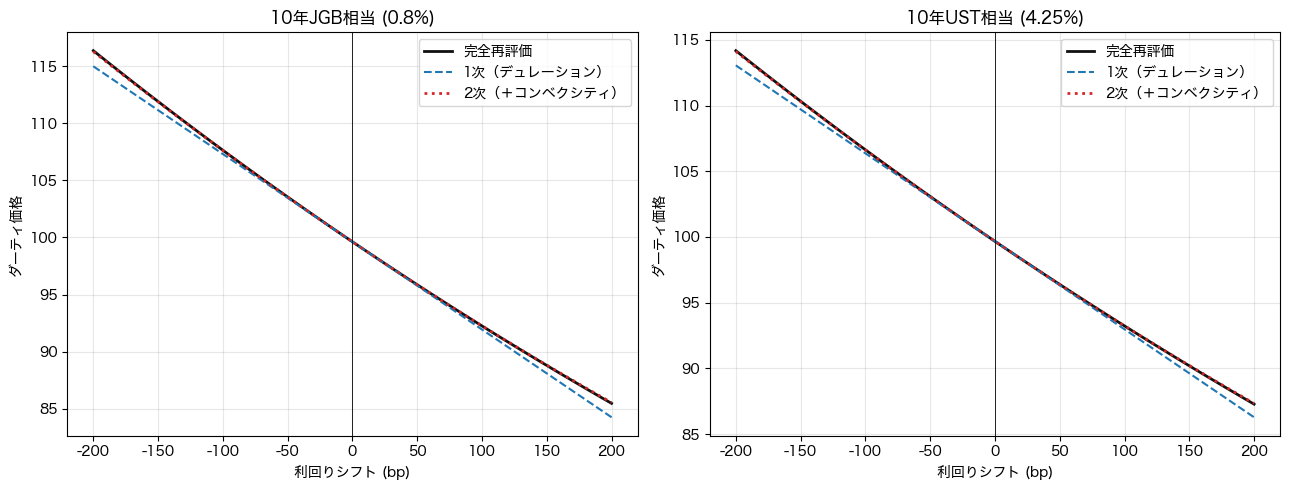

In [6]:
import matplotlib.pyplot as plt

import matplotlib.font_manager as _fm
for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Noto Sans JP", "TakaoPGothic", "IPAPGothic"]:
    if any(_f == _n.name for _n in _fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grid_dy = np.linspace(-0.02, 0.02, 81)  # ±200bp を連続で
for ax, (name, spec) in zip(axes, instruments.items()):
    b = FixedRateBond(spec["issue"], spec["maturity"], spec["coupon"], 2, "ACT/ACT", 100.0)
    y0 = spec["ytm"]
    risk = analytic_risk(b, y0, settle_real)
    p0 = risk["dirty_price"]
    p_true = np.array([b.dirty_price(y0 + dy, settle_real) for dy in grid_dy])
    p_lin = np.array([taylor_approx(risk, p0, dy)["linear"] for dy in grid_dy])
    p_quad = np.array([taylor_approx(risk, p0, dy)["quadratic"] for dy in grid_dy])
    ax.plot(grid_dy * 1e4, p_true, color="#111111", lw=2.0, label="完全再評価")
    ax.plot(grid_dy * 1e4, p_lin, "--", color="#1f77b4", label="1次（デュレーション）")
    ax.plot(grid_dy * 1e4, p_quad, ":", color="#d62728", lw=2.0, label="2次（＋コンベクシティ）")
    ax.axvline(0.0, color="k", lw=0.6)
    ax.set_title(name)
    ax.set_xlabel("利回りシフト (bp)")
    ax.set_ylabel("ダーティ価格")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1次近似（接線）はどちらの向きのシフトでも真値を下回る。価格-利回り曲線が下に凸
（$C>0$）で接線の上側にあるためで、この差こそコンベクシティの価値である。2次近似は
曲率を取り込むので真値にほぼ張り付き、$\pm 200\,\mathrm{bp}$ の端でわずかに離れるのは
打ち切った3次項の寄与である。

## 演習

1. 上の2銘柄について、$\pm 200\,\mathrm{bp}$ の1次近似・2次近似・完全再評価の誤差を
   比較し、シフト幅に対して各近似の誤差がどのオーダーで増えるか（$\Delta y$ の何乗か）を
   両対数プロットで確かめよ。
2. クーポンと満期を振り、修正デュレーションとコンベクシティがどう依存するかを
   可視化せよ。低クーポン・長満期でデュレーションとコンベクシティがともに大きくなる
   ことを図で示し、理由を一言で述べよ。

解答例は `solutions/S3/sol_0301.py` に置く。

## 用語集

定義の正は `glossary/03_risk.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| [修正デュレーション](../../glossary/03_risk.md#modified-duration) | modified duration | 利回りが1動いたときの価格の相対変化率。$-\frac1P\frac{dP}{dy}$ |
| [実効デュレーション](../../glossary/03_risk.md#effective-duration) | effective duration | 価格関数をバンプして数値微分した感応度。CF が金利依存でも使える |
| [コンベクシティ](../../glossary/03_risk.md#convexity) | convexity | 価格-利回り曲線の曲率。$\frac1P\frac{d^2P}{dy^2}$。通常は正 |
| [バンプ法](../../glossary/03_risk.md#bump-and-revalue) | bump-and-revalue | 入力を微小変化させ、価格差から感応度を数値微分する手法 |
| [テイラー展開](../../glossary/03_risk.md#taylor-expansion) | Taylor expansion | 関数を基準点まわりの多項式で近似する展開。価格変化の1次/2次近似の土台 |